# STEP TokaMaker + TORAX coupled flat-top (OpenSTEP SPP-001)

Coupled free-boundary equilibrium (TokaMaker) + transport (TORAX) simulation of
the STEP SPP-001 flat-top operating point, built from the
[OpenSTEP](https://github.com/ukaea/OpenSTEP) public data release (CC-BY 4.0,
see `data/LICENSE_OpenSTEP.txt`): wall and PF/CS coil geometry and shape
targets from the EB-CC free-boundary dataset, Ip/pressure targets and profile
shapes from the ftop equilibrium IDS, and the TORAX transport scenario loaded
verbatim from TORAX's own `step_flattop_bgb` example (EC-HD dataset; the two
flat-top operating points are treated as interchangeable). The ftop scenario
is a single steady-state operating point, so the target shape is held fixed
and the coupling relaxes the current and kinetic profiles self-consistently
over a 400 s window. The full run takes ~5 minutes on 4 cores (longer while
the JAX compilation cache is cold).

References: OpenSTEP data release, DOI
[10.14468/07jt-s540](https://doi.org/10.14468/07jt-s540); Tholerus et al.,
Nucl. Fusion 64 (2024) 106030.

In [1]:
import copy
import importlib.util
import os
import warnings

# Persistent JAX compilation cache -- must be set before torax/jax are first
# imported (via the pulse_design import below).
os.environ.setdefault('JAX_COMPILATION_CACHE_DIR',
                      os.path.join(os.path.expanduser('~'), '.cache', 'jax_torax'))

import imas
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

import OpenFUSIONToolkit
from OpenFUSIONToolkit import TokaMaker
from OpenFUSIONToolkit.TokaMaker import meshing
from OpenFUSIONToolkit.TokaMaker import pulse_design

import build_STEP_mesh
import build_seed_eqdsk

import torax
from torax._src import path_utils
from torax._src.config import config_loader
from torax._src.plotting import plotruns_lib

## Monkeypatches

Workarounds for current `TokaMaker_TORAX` (tmtx) behaviors, plus a wrapper
that captures the TORAX output DataTrees for the plots at the end.

In [2]:
# tmtx deep-merges the loaded config on top of its BASE_CONFIG and
# BASE_CONFIG-only keys survive. Clear the three defaults that are invalid
# for the step_flattop_bgb config (qlknn transport keys, mavrin_fit
# impurity-radiation keys, sawtooth MHD).
pulse_design.BASE_CONFIG['transport'] = {}
pulse_design.BASE_CONFIG['sources']['impurity_radiation'] = {}
pulse_design.BASE_CONFIG['mhd'] = {}

# The relax stages hardcode a 0.01 s TORAX timestep; at true resistivity
# the relax is insensitive to the step size, so run it 5x cheaper.
pulse_design.RELAX_FIXED_DT = 0.05

# TORAX rejects the ladder's initial nr=nz=100 saves for this tightly
# shaped double null; start at the 150 that is always accepted.
pulse_design.EQDSK_SAVE_NR_NZ_SEQUENCE = (150, 200, 250, 300, 350, 400, 450, 500)

# Isoflux weight for every shape target in the re-solves, raised 3x over
# the tmtx default so the equilibria hold STEP's full elongation and
# divertor legs against the coil-current regularization.
pulse_design.LCFS_WEIGHT = 300.0

In [3]:
# Fix the FF' decomposition handed to the re-solves (upstream tmtx
# issue): tmtx passes the total TORAX FF' as the Ip-scalable profile while
# also passing FF'_NI as a fixed component, so in this ~95% non-inductive
# plasma the scale factor's Ip leverage is degenerate and solves fall onto
# the profile-fallback ladder. Pass the inductive remainder
# FF'_total - FF'_NI as the scalable part instead.
_orig_tx_update = pulse_design.TokaMaker_TORAX._tx_update


def _tx_update_with_ffp_remainder(self, i, data_tree):
    if i == 0 and not hasattr(self, '_seed_prof_snapshot'):
        # Seed FF'/p' shapes for the t=0 substitution, re-read from the
        # eqdsk file (the copies tmtx keeps are normalized in place by an
        # on-axis FF' value of 0, leaving them inf/NaN). cocos=2 files
        # store -psi, so derivatives are sign-flipped to TokaMaker-native.
        g = pulse_design.read_eqdsk(build_seed_eqdsk.EQDSK_FILE)
        psi_eqdsk = np.linspace(0.0, 1.0, g['nr'])
        self._seed_prof_snapshot = {
            'ffp_prof': -np.interp(self._psi_N, psi_eqdsk, g['ffprim']),
            'pp_prof': -np.interp(self._psi_N, psi_eqdsk, g['pprime']),
        }
    _orig_tx_update(self, i, data_tree)
    if i == 0:
        # The TORAX t=0 profiles describe the start-up transient, but the
        # t=0 state is the seed equilibrium: hand the re-solve the seed's
        # own shapes, with the non-inductive component disabled.
        for key in ('ffp_prof', 'pp_prof'):
            self._state[key][0] = {'x': self._psi_N.copy(),
                                   'y': self._seed_prof_snapshot[key].copy(),
                                   'type': 'linterp'}
        self._state['ffp_ni_prof'][0] = None  # set_profiles skips a None NI profile
        return
    ffp_ni = np.asarray(self._state['ffp_ni_prof'][i]['y'], dtype=float)
    ffp_total = np.asarray(self._state['ffp_prof_tx'][i]['y'], dtype=float)
    if ffp_ni.size == ffp_total.size and np.any(ffp_ni):
        remainder = ffp_total - ffp_ni
        denom = ffp_total.sum()
        share = remainder.sum() / denom if denom != 0.0 else 0.0
        # Healthy timepoints have a remainder share of ~3-4; transiently
        # over-driven ones (net non-inductive current >= total) near or
        # below zero, where remainder scaling cannot fit Ip. 1.5 splits
        # the regimes with wide margin.
        if share > 1.5:
            self._state['ffp_prof'][i] = {'x': self._psi_N.copy(),
                                          'y': remainder,
                                          'type': 'linterp'}
        else:
            # Total FF' with the non-inductive component disabled: full
            # Ip leverage by construction.
            self._state['ffp_prof'][i] = {'x': self._psi_N.copy(),
                                          'y': ffp_total.copy(),
                                          'type': 'linterp'}
            self._state['ffp_ni_prof'][i] = None
    # Mild (sigma = 2 points, ~1% of the psi_N grid) shape-preserving
    # denoise: the profiles TORAX feeds back carry flux-surface-average
    # ripple from contouring the previous EQDSK, which otherwise
    # amplifies loop to loop.
    for key in ('ffp_prof', 'ffp_ni_prof', 'pp_prof'):
        prof = self._state[key][i]
        if prof is not None and np.atleast_1d(prof.get('y', [])).size > 10:
            prof['y'] = ndimage.gaussian_filter1d(np.asarray(prof['y'], dtype=float),
                                                  2.0, mode='nearest')


pulse_design.TokaMaker_TORAX._tx_update = _tx_update_with_ffp_remainder

In [4]:
# Capture every TORAX output DataTree for the plots at the end.
captured_trees = []
_original_run_simulation = torax.run_simulation


def _capturing_run_simulation(config, **kwargs):
    """Runs a TORAX simulation and records the output DataTree."""
    tree, history = _original_run_simulation(config, **kwargs)
    captured_trees.append(tree)
    return tree, history


torax.run_simulation = _capturing_run_simulation

## Mesh and seed equilibrium

In [5]:
if not os.path.exists(build_STEP_mesh.MESH_FILE):
    build_STEP_mesh.build_mesh()

In [6]:
if not os.path.exists(build_seed_eqdsk.EQDSK_FILE):
    build_seed_eqdsk.build_seed_equilibrium()

## Coupled simulation

In [7]:
T_INIT = 0.0
T_FINAL = 400.0  # matches step_flattop_bgb.py numerics.t_final
TX_DT = 10.0     # matches step_flattop_bgb.py numerics.fixed_dt
N_TM_TIMES = 5


def load_base_torax_config():
    """Loads TORAX's own step_flattop_bgb example config, with four deltas."""
    example_path = path_utils.torax_path() / 'examples' / 'step_flattop_bgb.py'
    spec = importlib.util.spec_from_file_location('step_flattop_bgb', example_path)
    module = importlib.util.module_from_spec(spec)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        spec.loader.exec_module(module)
    config = copy.deepcopy(module.CONFIG)

    # 1. TokaMaker_TORAX fully manages geometry, replacing the IMAS fixed-
    # boundary equilibrium with TokaMaker free-boundary EQDSKs.
    del config['geometry']

    # 2. True resistivity: the standalone 10x boost drives large current
    # excursions between equilibrium re-solves.
    config['numerics']['resistivity_multiplier'] = 1.0

    # 3. +10% EC power on the on-axis lobe (up to the inter-lobe minimum
    # of the bimodal deposition profile), so the flat top is slightly
    # over-driven and Ip recovers under the v_loop_lcfs = 0 condition.
    rho_ec, p_ec = config['sources']['ecrh']['extra_prescribed_power_density']
    rho_ec = np.asarray(rho_ec, dtype=float)
    p_ec = np.asarray(p_ec, dtype=float).copy()
    i_valley = int(np.argmin(np.where(rho_ec < 0.4, p_ec, np.inf)))
    p_ec[:i_valley + 1] *= 1.10
    config['sources']['ecrh']['extra_prescribed_power_density'] = (rho_ec, p_ec)

    # 4. Pellet rate retuned to the full-size free-boundary plasma
    # (a ~ 2.05); the standalone value over-fuels it (beta_N -> 5.5).
    config['sources']['pellet']['S_total'] = 2.4e21
    return config


def load_shape_targets():
    """Returns diverted-shape targets from the free-boundary equilibrium.

    Separatrix outline, curved divertor legs, and X-points all come from
    the free-boundary psi map (the fixed-boundary ftop outline sits
    0.15-0.25 m inside the true X-points). Shoulders and legs are grouped
    as strike targets because the tmtx re-solve trims isoflux points with
    |Z| > 0.6*max|Z|, which for this kappa~3 shape would discard them;
    strike_point_targets are appended after that trim.
    """
    sep = build_seed_eqdsk.load_freeboundary_separatrix()
    return {
        'x_points': sep['x_points'],
        'core': sep['core'],
        'strike_targets': np.vstack([sep['shoulders'], sep['legs']]),
        # full separatrix incl. legs, for plotting/overlays
        'boundary': np.vstack([sep['core'], sep['shoulders'], sep['legs']]),
    }


def build_tokamaker():
    """Builds the TokaMaker object and per-coil current bounds."""
    myOFT = OpenFUSIONToolkit.OFT_env(nthreads=4)
    mygs = TokaMaker.TokaMaker(myOFT)
    mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = meshing.load_gs_mesh(
        build_STEP_mesh.MESH_FILE)
    mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
    mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)
    # Healthy re-solves need up to ~250 iterations; 400 gives margin while
    # capping the cost of a failing fallback-ladder level.
    mygs.settings.maxits = 400

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        db = imas.DBEntry(build_seed_eqdsk.FTOP_FILE, 'r')
        vtf = db.get('equilibrium').vacuum_toroidal_field
        R0, B0 = float(vtf.r0), float(np.array(vtf.b0)[0])
        db.close()
    mygs.setup(order=2, F0=R0 * B0)

    # Virtual vertical-stability coil (see build_seed_eqdsk.py): required
    # for vertical feedback under up-down-symmetric coil currents.
    mygs.set_coil_vsc({'P3_COIL_U': 1.0, 'P3_COIL_L': -1.0})

    # Matches build_seed_eqdsk.py; not the binding constraint on shape.
    total_current_limit = 150.0E6
    coil_bounds = {}
    for name in mygs.coil_sets:
        nturns = coil_dict[name]['nturns'] if name in coil_dict else 1
        per_turn_limit = total_current_limit / max(nturns, 1)
        coil_bounds[name] = [-per_turn_limit, per_turn_limit]

    return mygs, coil_bounds

In [8]:
config = load_base_torax_config()
shape = load_shape_targets()
mygs, coil_bounds = build_tokamaker()

tmtx = pulse_design.TokaMaker_TORAX(
    t_init=T_INIT,
    t_final=T_FINAL,
    tx_dt=TX_DT,
    eqtimes=[T_INIT, T_FINAL],
    g_eqdsk_arr=[build_seed_eqdsk.EQDSK_FILE, build_seed_eqdsk.EQDSK_FILE],
    # 0.95 (not the 0.99 default): closer surfaces pass near the X-points
    # and TORAX's contour tracing rejects the saved EQDSK geometry.
    last_surface_factor=0.95,
    tm_times=np.linspace(T_INIT, T_FINAL, N_TM_TIMES),
    tokamaker_obj=mygs,
)

tmtx.set_TORAX_grid(grid_type='n_rho', grid=100)  # matches step_flattop_bgb.py

# The full TORAX scenario comes verbatim from the loaded config; no
# set_* overrides are used.
tmtx.load_TORAX_config(config)

# tmtx's config assembly unconditionally rebuilds the 'pedestal' section,
# so the loaded config's pedestal must be reinstalled explicitly.
tmtx.load_pedestal_config(config['pedestal'])

# Double-null targets, constant across the window; the saddle weight sits
# above the isoflux weight so the null positions win near the X-points.
tmtx.set_x_points(
    diverted_times=(T_INIT, T_FINAL),
    x_point_targets=shape['x_points'],
    x_point_weight=1000.0,
    strike_point_targets=shape['strike_targets'],
)

# Replace tmtx's per-timepoint isoflux targets: it derives them from the
# seed EQDSK boundary trace, which is the 95% flux surface rather than the
# separatrix, so re-solves would undershoot the elongation and X-points.
for i in range(len(tmtx._tm_times)):
    tmtx._state['lcfs_geo'][i] = shape['core'].copy()

# Up-down-symmetric coil currents (pair naming from build_STEP_mesh.py);
# the shape targets are symmetrized to match.
tmtx.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=True, default_weight=1.0E-3)

# Do not pre-populate tmtx._psi_warm_start[0]: key 0 also triggers
# TokaMaker's eddy-current solve mode against an unsolved reference state.

# set_fueling() initializes attributes tmtx references unconditionally;
# with no arguments it leaves the TORAX config unchanged.
tmtx.set_fueling()

# max_loop=2 reaches 0.000% convergence error. steady_state_mode: the
# ftop scenario is a single operating point, so later loops restart TORAX
# from the previous loop's t_final state (a fixed-point iteration) rather
# than replaying the start-up transient.
tmtx.fly(
    output_mode='minimal',
    max_loop=2,
    run_name='STEP_ftop',
    relax=True,
    relax_duration=2,
    steady_state_mode=True,
)

print(tmtx.summary())


  Max loop index (2) reached (err=0.000%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      -0.0000          1.6277           100.0000      
  2      -0.0000          2.1000           100.0000      
  Total sim time: 4m 1.4s
  Outputs saved to: ./TokaMaker_TORAX_outputs/STEP_ftop_2026-07-13_092008
  Log file: /home/user/OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/STEP_TokaMaker_TORAX/TokaMaker_TORAX_log_STEP_ftop_2026-07-13_092008.log

  TokaMaker_TORAX Physics Summary
  Q_max                           9.097
  Q_max_time                      10
  Q_flattop_avg                   8.483
  E_fusion_total_MJ               4.418e+05
  beta_N_max                      4.238
  H98_max                         1.153
  H98_flattop_avg                 1.141
  T_e_core_max_keV                18.02
  T_i_core_max_keV                18.85
  n_e_line_avg_max                1.661e+20
  f_GW_max         

## Results

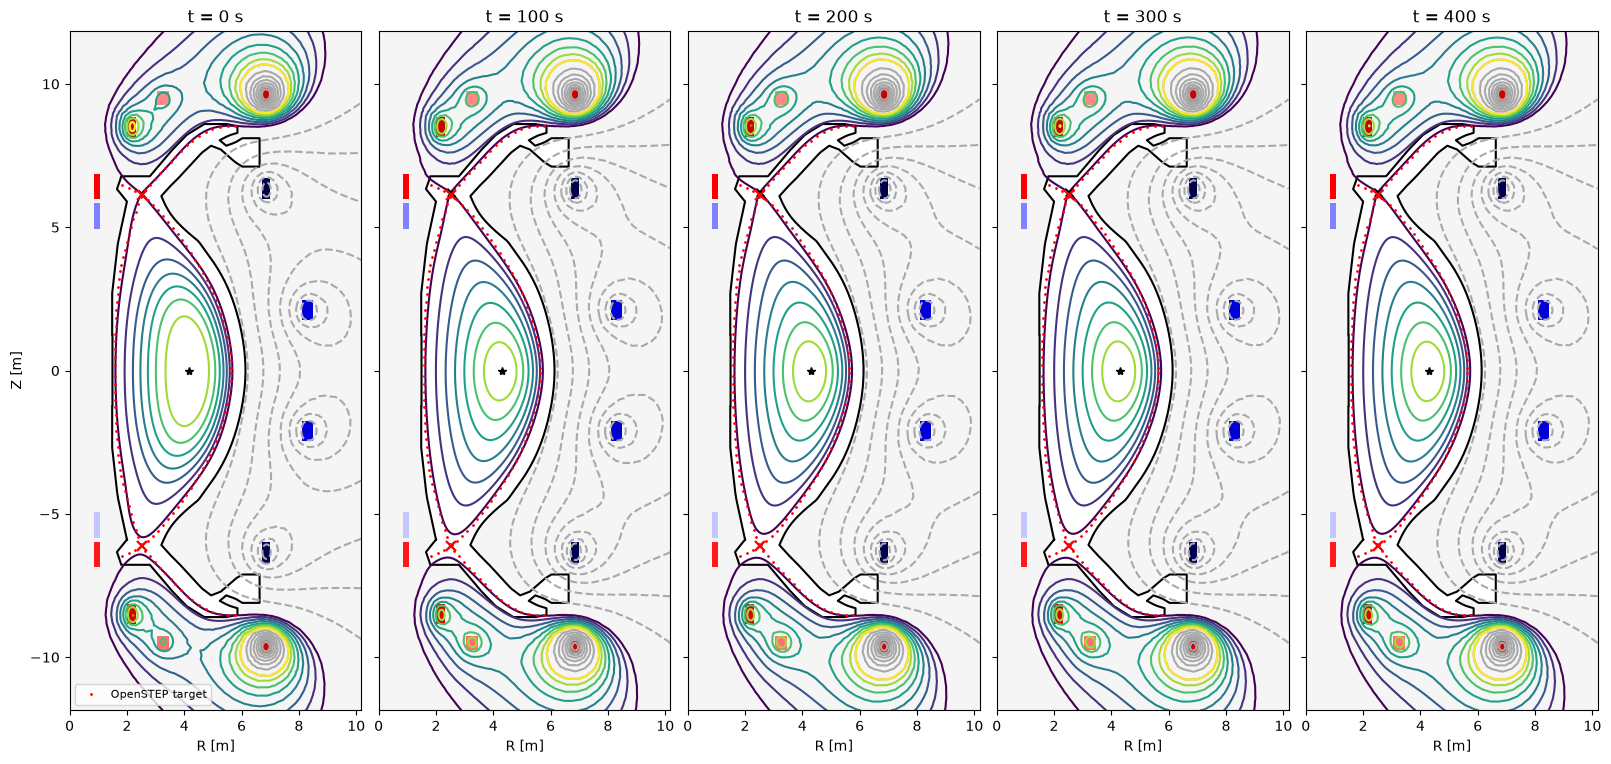

In [9]:
targets = load_shape_targets()
final_loop = max(tmtx._tm_psi_on_nodes)
times = tmtx._tm_times

fig, axes = plt.subplots(1, len(times), figsize=(3.2 * len(times), 8.0),
                         sharey=True, constrained_layout=True)
for ax, (i, t) in zip(axes, enumerate(times)):
    psi = np.ascontiguousarray(tmtx._tm_psi_on_nodes[final_loop][i], dtype=np.float64)
    mygs.set_psi(psi, update_bounds=True)
    mygs.plot_machine(fig, ax, coil_colormap='seismic', coil_scale=1.0e-6,
                      coil_clabel=None, coil_symmap=True)
    mygs.plot_psi(fig, ax, plasma_nlevels=8, vacuum_nlevels=8)
    ax.plot(targets['boundary'][:, 0], targets['boundary'][:, 1], 'r.', ms=2.0,
            label='OpenSTEP target' if i == 0 else None)
    ax.plot(targets['x_points'][:, 0], targets['x_points'][:, 1], 'rx', ms=7, mew=1.6)
    ax.set_title(f't = {t:.0f} s')
    ax.set_xlabel('R [m]')
axes[0].set_ylabel('Z [m]')
axes[0].legend(loc='lower left', fontsize=8)
plt.show()

In [10]:
final_tree = [tree for tree in captured_trees
              if np.asarray(tree.time)[-1] >= T_FINAL][-1]
plot_config = config_loader.import_module(
    'plotting/configs/default_plot_config.py')['PLOT_CONFIG']
torax_fig = plotruns_lib.plot_run_from_data_tree(plot_config, {'STEP_ftop': final_tree})